In [2]:
# Note: After you run this cell, the training and test data will be available in
# the file browser. (Click the folder icon on the left to view it)
#
# If you don't see the data after the cell completes, click the refresh button
# in the file browser (folder icon with circular arrow)

# First, let's download and unzip the data
!echo "Downloading files..."
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training1.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training2.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout_answers.csv

!echo "Unzipping files..."
!unzip -q /content/training1.zip
!unzip -q /content/training2.zip
!unzip -q /content/holdout.zip
!unzip -q /content/mini_holdout.zip

# Combine the two traning directories
!echo "Merging training data..."
!mkdir /content/training
!mv /content/training1/* /content/training
!mv /content/training2/* /content/training

# Cleanup
!echo "Cleaning up..."
!rmdir /content/training1
!rmdir /content/training2
!rm training1.zip
!rm training2.zip
!rm holdout.zip
!rm mini_holdout.zip

!echo "Data ready."

Unzipping files...
Merging training data...
Cleaning up...
Data ready.


In [3]:
# Import libraries
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# We're using keras' ImageDataGenerator class to load our image data.
# See (https://keras.io/api/preprocessing/image/#imagedatagenerator-class) for details
#
# A couple of things to note:
# 1. We're specifying a number for the seed, so we'll always get the same shuffle and split of our images.
# 2. Class names are inferred automatically from the image subdirectory names.
# 3. We're splitting the training data into 80% training, 20% validation.


training_dir = '/content/training/'
image_size = (224, 224)

# Split up the training data images into training and validations sets
# We'll use and ImageDataGenerator to do the splits
# ImageDataGenerator can also be used to do preprocessing and agumentation on the files as can be seen with rescale

train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=.2
        )
validation_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=.2
        )

train_generator = train_datagen.flow_from_directory(
        training_dir,
        target_size = image_size,
        subset="training",
        batch_size=32,
        class_mode='sparse',
        seed=42,shuffle=True)
validation_generator = validation_datagen.flow_from_directory(
        training_dir,
        target_size=image_size,
        batch_size=32,
        class_mode='sparse',
        subset="validation",
        seed=42)



Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


In [5]:
#these might come in handy
target_names = ['Speed_20', 'Speed_30', 'Speed_50', 'Speed_60', 'Speed_70',
               'Speed_80','Speed_Limit_Ends', 'Speed_100', 'Speed_120', 'Overtaking_Prohibited',
               'Overtakeing_Prohibited_Trucks', 'Priority', 'Priority_Road_Ahead', 'Yield', 'STOP',
               'Entry_Forbidden', 'Trucks_Forbidden', 'No_Entry(one-way traffic)', 'General Danger(!)', 'Left_Curve_Ahead',
               'Right_Curve_Ahead', 'Double_Curve', 'Poor_Surface_Ahead', 'Slippery_Surface_Ahead', 'Road_Narrows_On_Right',
               'Roadwork_Ahead', 'Traffic_Light_Ahead', 'Warning_Pedestrians', 'Warning_Children', 'Warning_Bikes',
               'Ice_Snow', 'Deer_Crossing', 'End_Previous_Limitation', 'Turning_Right_Compulsory', 'Turning_Left_Compulsory',
               'Ahead_Only', 'Straight_Or_Right_Mandatory', 'Straight_Or_Left_Mandatory', 'Passing_Right_Compulsory', 'Passing_Left_Compulsory',
               'Roundabout', 'End_Overtaking_Prohibition', 'End_Overtaking_Prohibition_Trucks']

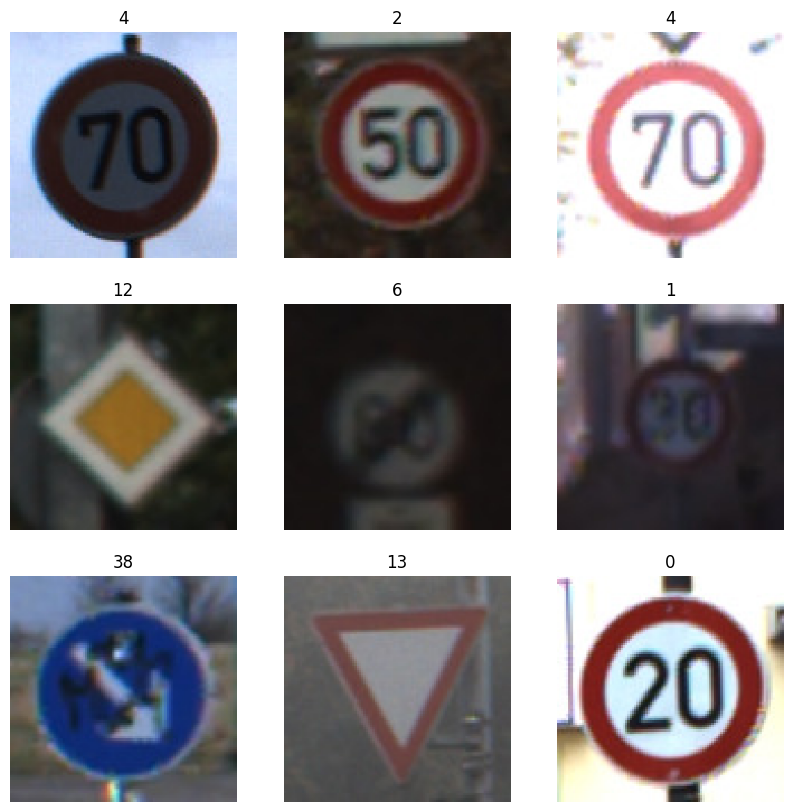

In [5]:
# View 9 images and their class labels
plt.figure(figsize=(10, 10))
images, labels = next(train_generator)  # Assuming train_generator is a generator
batch_size = images.shape[0]

for i in range(min(9, batch_size)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] * 255).astype("uint8"))
    plt.title(int(labels[i]))
    plt.axis("off")

plt.show()

In [6]:
# Build a model... VGG-16
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Load pretrained VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze convolution layers
for layer in base_model.layers:
    layer.trainable = False

# Build classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(target_names), activation='softmax')
])

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,859,115 (56.68 MB)

 Trainable params: 143,403 (560.17 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 226s 215ms/step - accuracy: 0.4892 - loss: 1.7956 - val_accuracy: 0.5326 - val_loss: 1.6896
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 213s 217ms/step - accuracy: 0.6516 - loss: 1.1596 - val_accuracy: 0.5652 - val_loss: 1.6169
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 212s 216ms/step - accuracy: 0.6997 - loss: 0.9750 - val_accuracy: 0.5719 - val_loss: 1.6444
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 212s 216ms/step - accuracy: 0.7309 - loss: 0.8699 - val_accuracy: 0.5976 - val_loss: 1.6125
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 212s 216ms/step - accuracy: 0.7484 - loss: 0.8041 - val_accuracy: 0.5842 - val_loss: 1.6557
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 211s 216ms/step - accuracy: 0.7645 - loss: 0.7498 - val_accuracy: 0.5976 - val_loss: 1.6851
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 212s 216ms/step - accuracy: 0.7796 - loss: 0.7055 - val_accuracy: 0.5939 - val_loss: 1.7182
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 212s 216ms/step - accuracy: 0.7902 -

In [22]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['mini_holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]

Found 201 images belonging to 1 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step


In [23]:
answers = pd.read_csv('/content/mini_holdout_answers.csv')

true_labels = answers['ClassId']

In [24]:
accuracy = np.mean(predictions == true_labels)

print("Mini Holdout Accuracy:", accuracy)

Mini Holdout Accuracy: 0.6915422885572139


In [25]:
wrong = np.where(predictions != true_labels)[0]

print("Number of mistakes:", len(wrong))

Number of mistakes: 62


 **ResNet**

In [14]:
# ResNet

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load pretrained ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classification head
model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(target_names), activation='softmax')
])

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,131,499 (92.05 MB)

 Trainable params: 539,691 (2.06 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [15]:
model_resnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history_resnet = model_resnet.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 132s 121ms/step - accuracy: 0.3944 - loss: 2.1729 - val_accuracy: 0.4728 - val_loss: 1.8321
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 107s 109ms/step - accuracy: 0.5741 - loss: 1.4352 - val_accuracy: 0.5825 - val_loss: 1.5763
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 106s 108ms/step - accuracy: 0.6455 - loss: 1.1864 - val_accuracy: 0.5984 - val_loss: 1.5257
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 106s 108ms/step - accuracy: 0.6797 - loss: 1.0578 - val_accuracy: 0.6457 - val_loss: 1.3851
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 106s 108ms/step - accuracy: 0.7116 - loss: 0.9602 - val_accuracy: 0.6471 - val_loss: 1.3859
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 105s 107ms/step - accuracy: 0.7341 - loss: 0.8824 - val_accuracy: 0.6541 - val_loss: 1.4160
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 105s 107ms/step - accuracy: 0.7421 - loss: 0.8426 - val_accuracy: 0.6571 - val_loss: 1.3653
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 105s 107ms/step - accuracy: 0.7586 -

In [26]:
test_loss, test_acc = model_resnet.evaluate(validation_generator)

print("ResNet Accuracy:", test_acc)

246/246 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.6864 - loss: 1.2633
ResNet Accuracy: 0.686392068862915


In [27]:
probabilities = model_resnet.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 985ms/step


In [28]:
accuracy = np.mean(predictions == true_labels)

print("Mini Holdout Accuracy:", accuracy)

Mini Holdout Accuracy: 0.681592039800995


**Inception**

In [18]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models

# Load pretrained Inception model
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze convolution layers
for layer in base_model.layers:
    layer.trainable = False

# Build classification head
model_inception = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(target_names), activation='softmax')
])

model_inception.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_96          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,346,571 (85.25 MB)

 Trainable params: 539,691 (2.06 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

In [19]:
model_inception.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history_inception = model_inception.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 117s 103ms/step - accuracy: 0.7314 - loss: 0.9438 - val_accuracy: 0.7151 - val_loss: 1.0317
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.8689 - loss: 0.4072 - val_accuracy: 0.7306 - val_loss: 1.1170
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.8881 - loss: 0.3416 - val_accuracy: 0.7292 - val_loss: 1.1680
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.9042 - loss: 0.2927 - val_accuracy: 0.7408 - val_loss: 1.1879
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.9147 - loss: 0.2569 - val_accuracy: 0.7389 - val_loss: 1.3654
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.9198 - loss: 0.2488 - val_accuracy: 0.7318 - val_loss: 1.2878
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.9273 - loss: 0.2246 - val_accuracy: 0.7368 - val_loss: 1.4008
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.9300 - loss: 0.2164 

In [21]:
test_loss, test_acc = model_inception.evaluate(validation_generator)

print("Inception Accuracy:", test_acc)

246/246 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.7496 - loss: 1.4500
Inception Accuracy: 0.7496492862701416


In [29]:
probabilities = model_inception.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]

7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step


In [30]:
accuracy = np.mean(predictions == true_labels)

print("Mini Holdout Accuracy:", accuracy)

Mini Holdout Accuracy: 0.7960199004975125


## Testing the model
Once you have built and trained your model, the next step is to run the mini holdout images through it and see how well your model does at making predictions for images it has never seen before.

Since loading these images and formatting them for the model can be tricky, you may find the following code useful. This code only uses your model to predict the class label for a given image. You'll still need to compare those predictions to the "ground truth" class labels in `mini_holdout_answers.csv` to evaluate how well the model does.

Previously, you were given a file that would check your results. This time you're given the answers to the first mini holdout dataset. You'll need to compare those predictions against the "ground truth" class labels in `mini_holdout_answers.csv` to evaluate how well the model does.

Make sure to use the insights gained from the mini hold out dataset in your executive summary.


```
from tensorflow.keras.preprocessing import image_dataset_from_directory
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['mini_holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]
```



##Mini Hold out Dataset


Once you feel confident, you will need to predict for the full holdout dataset using the following code, and submit your csv file:

```
from tensorflow.keras.preprocessing import image_dataset_from_directory
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]
```